In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
path = "/content/drive/MyDrive/Infosys_Model.xlsx"
df = pd.read_excel(path, sheet_name="Dashboard")
# Look at the first 5 rows
df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Projected
0,NaN,Year,Mar-17,Mar-18,Mar-19,Mar-20,Mar-21,Mar-22,Mar-23,Mar-24,Mar-25,Mar-26,Mar-27
1,Revenue(Rs. Cr),NaN,68484,70522,82675,90791,100472,121641,146767,153670,162990,178650,192942
2,Net Profit,NaN,14353,16029,15410,16639,19423,22146,24108,26248,26750,29474,31088.037862
3,EBIDTA Margin %,NaN,0.302709,0.299771,0.269434,0.267859,0.293066,0.272608,0.253104,0.259728,0.257134,0.249407,0.249


In [4]:

df = pd.read_excel(path, sheet_name="Dashboard", header=1)
df = df.dropna(axis=1, how='all')
df.head()


,Unnamed: 0,Mar-17,Mar-18,Mar-19,Mar-20,Mar-21,Mar-22,Mar-23,Mar-24,Mar-25,Mar-26,Mar-27
0,Revenue(Rs. Cr),68484.000000,70522.000000,82675.000000,90791.000000,100472.000000,121641.000000,146767.000000,153670.000000,162990.000000,178650.000000,192942.000000
1,Net Profit,14353.000000,16029.000000,15410.000000,16639.000000,19423.000000,22146.000000,24108.000000,26248.000000,26750.000000,29474.000000,31088.037862
2,EBIDTA Margin %,0.302709,0.299771,0.269434,0.267859,0.293066,0.272608,0.253104,0.259728,0.257134,0.249407,0.249000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  3 non-null      object 
 1   Mar-17      3 non-null      float64
 2   Mar-18      3 non-null      float64
 3   Mar-19      3 non-null      float64
 4   Mar-20      3 non-null      float64
 5   Mar-21      3 non-null      float64
 6   Mar-22      3 non-null      float64
 7   Mar-23      3 non-null      float64
 8   Mar-24      3 non-null      float64
 9   Mar-25      3 non-null      float64
 10  Mar-26      3 non-null      float64
 11  Mar-27      3 non-null      float64
dtypes: float64(11), object(1)
memory usage: 420.0+ bytes


In [6]:
projected_profit_2027 = df.at[2, 'Mar-27']
print(f"Projected Profit for 2027: ₹{projected_profit_2027:,.2f} Cr")


Projected Profit for 2027: ₹0.25 Cr


In [7]:
import yfinance as yf

#Connect to the API
infy = yf.Ticker("INFY.NS")

#Get the current market price
live_price = infy.history(period="1d")['Close'].iloc[-1]

#Calculate the Upside
target_price_excel = 1893.6
upside_percentage = ((target_price_excel - live_price) / live_price) * 100

print(f"Live Price: ₹{live_price:.2f}")
print(f"Projected Upside: {upside_percentage:.2f}%")

Live Price: ₹1175.50
Projected Upside: 61.09%


In [8]:
# We use .loc[row_condition, column_name]
net_profit_row = df[df.iloc[:, 0].str.contains("Net Profit", na=False)]
projected_profit_2027 = net_profit_row['Mar-27'].values[0]
print(f"Corrected Projected Profit for 2027: ₹{projected_profit_2027:,.2f} Cr")

Corrected Projected Profit for 2027: ₹31,088.04 Cr


In [1]:
import sqlite3
import pandas as pd

#Connect to the database file
conn = sqlite3.connect('nifty_portfolio.db')
c = conn.cursor()
#Table 1: Company Metadata
c.execute('''CREATE TABLE IF NOT EXISTS Company_Registry
             (Ticker TEXT PRIMARY KEY, Name TEXT, Sector TEXT)''')

#Table 2: Financial Metrics
c.execute('''CREATE TABLE IF NOT EXISTS Stock_Metrics
             (Ticker TEXT, Price REAL, Five_Year_Avg_PE REAL, Current_PE REAL,
             FOREIGN KEY (Ticker) REFERENCES Company_Registry(Ticker))''')
conn.commit()

In [3]:
#Sample data for 50+ Nifty tickers
registry_data = [('INFY', 'Infosys', 'Tech'), ('TCS', 'Tata Consultancy', 'Tech'), ('HDFC', 'HDFC Bank', 'Banking')]
metrics_data = [('INFY', 1450, 28.5, 22.1), ('TCS', 3200, 30.0, 29.5), ('HDFC', 1500, 22.0, 16.5)]

c.executemany('INSERT OR REPLACE INTO Company_Registry VALUES (?,?,?)', registry_data)
c.executemany('INSERT OR REPLACE INTO Stock_Metrics VALUES (?,?,?,?)', metrics_data)
conn.commit()

In [4]:
#Joining tables and filtering for value
query = """
SELECT r.Name, m.Ticker, m.Current_PE, m.Five_Year_Avg_PE
FROM Company_Registry r
JOIN Stock_Metrics m ON r.Ticker = m.Ticker
WHERE m.Current_PE <= (m.Five_Year_Avg_PE * 0.80);
"""
discounted_portfolio = pd.read_sql_query(query, conn)
print("--- VALUE INVESTING SCREEN RESULTS ---")
print(discounted_portfolio)

--- VALUE INVESTING SCREEN RESULTS ---
        Name Ticker  Current_PE  Five_Year_Avg_PE
0    Infosys   INFY        22.1              28.5
1  HDFC Bank   HDFC        16.5              22.0
2    Infosys   INFY        22.1              28.5
3  HDFC Bank   HDFC        16.5              22.0


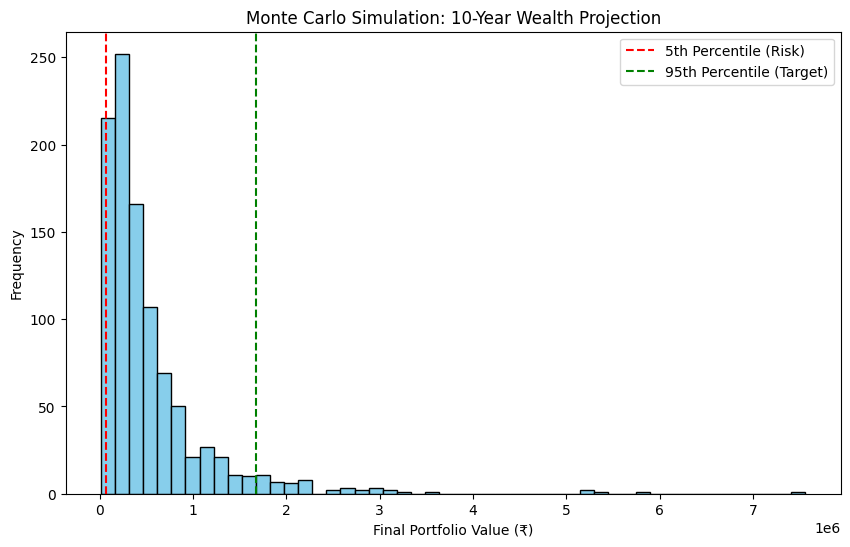

95% Confidence Interval: ₹67,097.32 to ₹1,675,739.46


In [5]:
import numpy as np
import matplotlib.pyplot as plt
initial_investment = 100000
years = 10
annual_return = 0.12
volatility = 0.30  # 30% risk factor
simulations = 1000

results = []
for i in range(simulations):
    # Simulating random market movements
    daily_returns = np.random.normal(annual_return/252, volatility/np.sqrt(252), 252*years)
    final_value = initial_investment * np.exp(np.sum(daily_returns))
    results.append(final_value)

plt.figure(figsize=(10, 6))
plt.hist(results, bins=50, color='skyblue', edgecolor='black')
plt.axvline(np.percentile(results, 5), color='red', linestyle='--', label='5th Percentile (Risk)')
plt.axvline(np.percentile(results, 95), color='green', linestyle='--', label='95th Percentile (Target)')
plt.title('Monte Carlo Simulation: 10-Year Wealth Projection')
plt.xlabel('Final Portfolio Value (₹)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print(f"95% Confidence Interval: ₹{np.percentile(results, 5):,.2f} to ₹{np.percentile(results, 95):,.2f}")